# 02 elo validation


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, brier_score_loss
import seaborn as sns

# Load data
df = pd.read_csv('data/raw/results.csv', parse_dates=['date'])

In [11]:
class EloCalculator:
    def __init__(self, initial_rating=1500, k_factor=32, home_advantage=100):
        self.ratings = {}
        self.k_factor = k_factor
        self.home_advantage = home_advantage
        self.initial_rating = initial_rating
    
    def expected_score(self, rating_a, rating_b, home_advantage=0):
        # Add home advantage to rating_a if home team
        rating_a_adj = rating_a + home_advantage
        return 1 / (1 + 10 ** ((rating_b - rating_a_adj) / 400))
    
    def update_ratings(self, home_team, away_team, home_score, away_score, date, tournament):
        # Initialize ratings if new teams
        if home_team not in self.ratings:
            self.ratings[home_team] = self.initial_rating
        if away_team not in self.ratings:
            self.ratings[away_team] = self.initial_rating
        
        # Determine K-factor based on tournament importance
        k = self.k_factor
        if tournament == 'FIFA World Cup':
            k = 40
        
        # Calculate expected scores
        expected_home = self.expected_score(
            self.ratings[home_team], self.ratings[away_team], self.home_advantage
        )
        expected_away = 1 - expected_home
        
        # Actual results (1 = win, 0.5 = draw, 0 = loss)
        if home_score > away_score:
            actual_home, actual_away = 1, 0
        elif home_score < away_score:
            actual_home, actual_away = 0, 1
        else:
            actual_home, actual_away = 0.5, 0.5
        
        # Update ratings
        self.ratings[home_team] += k * (actual_home - expected_home)
        self.ratings[away_team] += k * (actual_away - expected_away)

In [12]:
elo = EloCalculator(k_factor=32, home_advantage=100)
results = []

for idx, row in df.iterrows():
    elo.update_ratings(
        row['home_team'], row['away_team'],
        row['home_score'], row['away_score'],
        row['date'], row['tournament']
    )
    
    # Track ratings over time
    results.append({
        'date': row['date'],
        'home_team': row['home_team'],
        'away_team': row['away_team'],
        'home_rating': elo.ratings[row['home_team']],
        'away_rating': elo.ratings[row['away_team']],
    })

# Save final ratings
final_ratings = pd.DataFrame([
    {'team': team, 'elo': rating} 
    for team, rating in elo.ratings.items()
]).sort_values('elo', ascending=False)
final_ratings.to_csv('data/processed/elo_ratings.csv', index=False)

In [13]:
# Backtest on 2018 and 2022 World Cups
test_years = [2018, 2022]
for year in test_years:
    # Filter test data
    test_matches = df[(df['date'].dt.year == year) & (df['tournament'] == 'FIFA World Cup')]
    
    # Calculate predictions using Elo ratings BEFORE match
    # (Implement rolling Elo where ratings only use historical data)
    
    # Calculate accuracy metrics
    # Log loss, Brier score, accuracy

In [14]:
# Backtest on 2018 and 2022 World Cups with rolling Elo (only using historical data)
test_years = [2018, 2022]
all_predictions = []

for year in test_years:
    print(f"\n--- Testing on {year} World Cup ---")
    
    # Reset Elo for backtest (train only on data before the tournament)
    elo_backtest = EloCalculator(k_factor=32, home_advantage=100)
    
    # Train on all matches BEFORE the tournament
    train_matches = df[df['date'] < f'{year}-01-01']
    
    print(f"Training on {len(train_matches):,} matches before {year}")
    
    for idx, row in train_matches.iterrows():
        elo_backtest.update_ratings(
            row['home_team'], row['away_team'],
            row['home_score'], row['away_score'],
            row['date'], row['tournament']
        )
    
    # Predict World Cup matches
    test_matches = df[(df['date'].dt.year == year) & (df['tournament'] == 'FIFA World Cup')]
    
    for idx, row in test_matches.iterrows():
        # Get ratings before match
        home_rating = elo_backtest.ratings.get(row['home_team'], 1500)
        away_rating = elo_backtest.ratings.get(row['away_team'], 1500)
        
        # Calculate win probabilities
        exp_home = elo_backtest.expected_score(home_rating, away_rating, elo_backtest.home_advantage)
        exp_away = 1 - exp_home
        exp_draw = 0.25  # Baseline draw probability (adjust based on historical)
        
        # Normalize to 3 outcomes
        win_home = exp_home * (1 - exp_draw)
        win_away = exp_away * (1 - exp_draw)
        
        # Actual outcome
        if row['home_score'] > row['away_score']:
            actual = 0  # Home win
        elif row['home_score'] < row['away_score']:
            actual = 2  # Away win
        else:
            actual = 1  # Draw
        
        all_predictions.append({
            'year': year,
            'home_team': row['home_team'],
            'away_team': row['away_team'],
            'prob_home': win_home,
            'prob_draw': exp_draw,
            'prob_away': win_away,
            'actual': actual,
            'home_rating': home_rating,
            'away_rating': away_rating
        })

# Convert to DataFrame
pred_df = pd.DataFrame(all_predictions)
print(f"\nTotal predictions: {len(pred_df)}")
pred_df.head()


--- Testing on 2018 World Cup ---
Training on 41,297 matches before 2018

--- Testing on 2022 World Cup ---
Training on 44,837 matches before 2022

Total predictions: 128


,year,home_team,away_team,prob_home,prob_draw,prob_away,actual,home_rating,away_rating
0,2018,Russia,Saudi Arabia,0.552427,0.25,0.197573,0,1708.196770,1629.577939
1,2018,Egypt,Uruguay,0.338526,0.25,0.411474,2,1711.255987,1845.156221
2,2018,Morocco,Iran,0.339350,0.25,0.410650,2,1690.137484,1823.267430
3,2018,Portugal,Spain,0.399025,0.25,0.350975,1,1901.456843,1979.167473
4,2018,France,Australia,0.628945,0.25,0.121055,0,1929.348009,1743.095733


In [15]:
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score

# Prepare arrays for metrics
y_true = []
y_prob_home = []
y_prob_draw = []
y_prob_away = []

for _, row in pred_df.iterrows():
    y_true.append(row['actual'])
    y_prob_home.append(row['prob_home'])
    y_prob_draw.append(row['prob_draw'])
    y_prob_away.append(row['prob_away'])

y_prob = np.column_stack([y_prob_home, y_prob_draw, y_prob_away])

# Calculate metrics
log_loss_val = log_loss(y_true, y_prob)
brier_val = brier_score_loss(np.array(y_true) == 0, y_prob_home)  # For home wins
accuracy = accuracy_score(y_true, np.argmax(y_prob, axis=1))

print("Elo Model Performance on 2018+2022 World Cups")
print("=" * 50)
print(f"Log Loss: {log_loss_val:.4f}")
print(f"Brier Score (home wins): {brier_val:.4f}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

Elo Model Performance on 2018+2022 World Cups
Log Loss: 1.0262
Brier Score (home wins): 0.2172
Accuracy: 0.5078 (50.8%)


In [16]:
# Show top 20 teams by Elo rating
print("\nTop 20 Teams by Elo Rating")
print("=" * 40)
final_ratings.head(20)


Top 20 Teams by Elo Rating


,team,elo
7,Argentina,2018.632621
40,Spain,1999.064138
12,France,1979.099921
33,Brazil,1928.182081
85,Colombia,1921.957340
49,Portugal,1921.430766
21,Germany,1901.773004
1,England,1893.599961
25,Italy,1893.036972
88,Ecuador,1892.679004


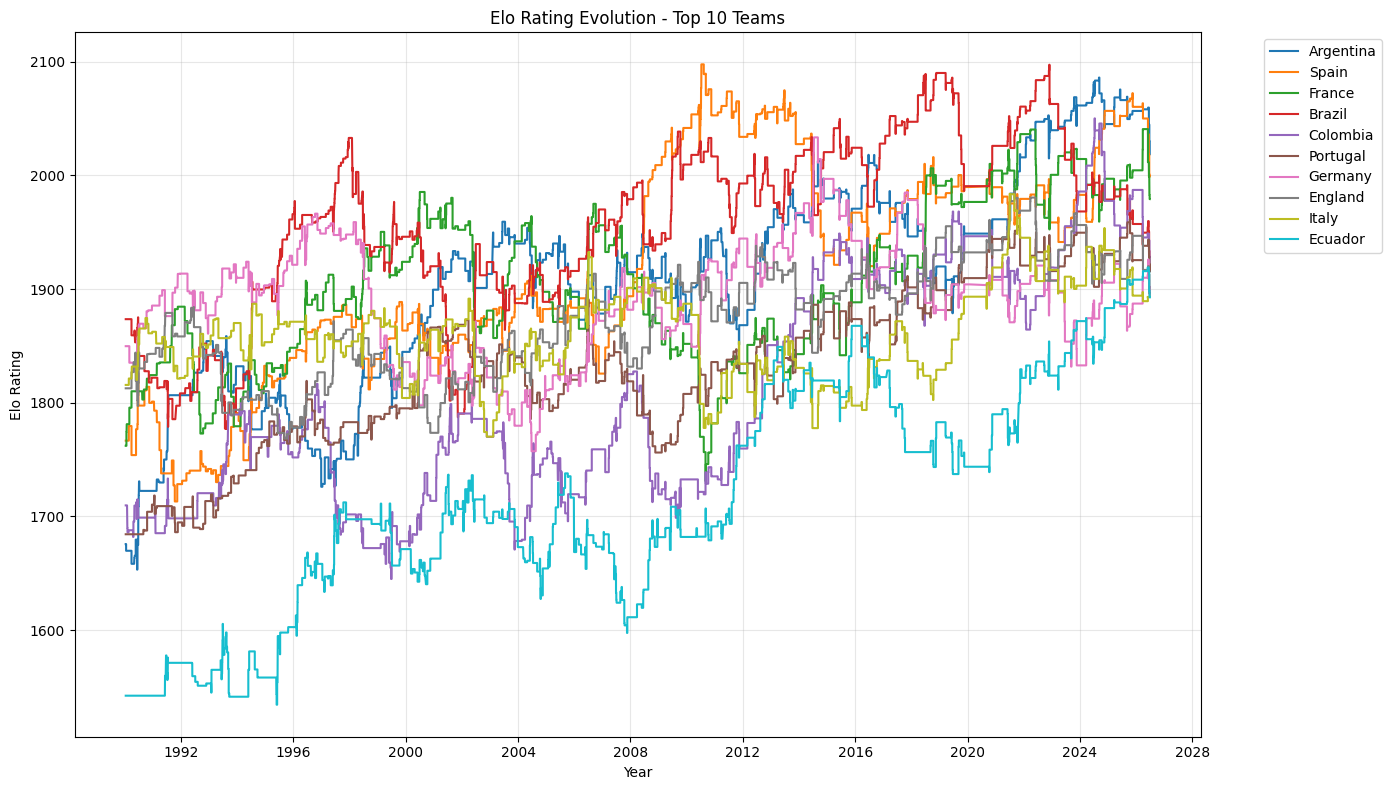

In [17]:
# Track Elo over time for top teams
top_teams = final_ratings.head(10)['team'].tolist()

# Re-run to get historical ratings
elo_history = EloCalculator(k_factor=32, home_advantage=100)
history_data = []

for idx, row in df.iterrows():
    elo_history.update_ratings(
        row['home_team'], row['away_team'],
        row['home_score'], row['away_score'],
        row['date'], row['tournament']
    )
    
    if row['date'].year >= 1990:  # Track from 1990 onwards
        for team in top_teams:
            if team in elo_history.ratings:
                history_data.append({
                    'date': row['date'],
                    'team': team,
                    'elo': elo_history.ratings[team]
                })

history_df = pd.DataFrame(history_data)

# Plot
plt.figure(figsize=(14, 8))
for team in top_teams:
    team_data = history_df[history_df['team'] == team]
    if len(team_data) > 0:
        plt.plot(team_data['date'], team_data['elo'], label=team, linewidth=1.5)

plt.xlabel('Year')
plt.ylabel('Elo Rating')
plt.title('Elo Rating Evolution - Top 10 Teams')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()